# AR aggregation ablation (species tutorial subset)

Companion to `custom_model_tutorial_standard_vs_AR.ipynb` for **Reviewer 1** (alternative AR aggregation rules).

Uses the same prepared file as the custom tutorial: `data/species_for_AR_example.h5ad`.

The manuscript uses **coordinate-wise max** over per-axis inverse densities (default sc-AR). Other rules are possible; this notebook trains the **same small autoencoder** with:

| Method | Aggregation |
|---|---|
| **Standard** | Uniform sampling (no AR) |
| **AR-max** | Max over latent axes (**manuscript default**) |
| **AR-mean** | Mean over latent axes |
| **AR-product** | Product of per-axis weights (joint under independence; Amini et al. style) |
| **AR-knn** | Inverse mean $k$-NN distance (nonparametric joint-density proxy) |

This is a **mini analysis** for interested readers — not a full benchmark. Macro-averaged reconstruction MSE highlights rare cell populations.

### Imports

In [12]:
import sys, os, random, warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import scanpy as sc
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().resolve()
if ROOT.name == "rebuttal_analysis":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

from rebuttal_analysis.ar_aggregation_variants import (
    calculate_resampling_weights_with_method,
)

OUT_DIR = ROOT / "rebuttal_analysis" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("cwd:", Path.cwd())

cwd: /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR


### Load data

We use the same ready-made subset as the custom tutorial: `data/species_for_AR_example.h5ad` (~5,000 cells × 2,000 HVGs, imbalanced Louvain populations in `obs["str_labels"]`). Expression is already library-size normalized and log1p-transformed.

If the file is missing, build it with:

```bash
python scripts/make_species_for_AR_example.py \
  --input data/species.h5ad \
  --output data/species_for_AR_example.h5ad
```

In [13]:
SEED = 42
DATA_PATH = ROOT / "data" / "species_for_AR_example.h5ad"
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing {DATA_PATH}. Build it with:\n"
        "  python scripts/make_species_for_AR_example.py "
        "--input data/species.h5ad --output data/species_for_AR_example.h5ad"
    )

adata = sc.read_h5ad(DATA_PATH)
label_col = "str_labels"
assert label_col in adata.obs.columns

print(f"Species tutorial subset shape: {adata.shape}")
print("\nCell population distribution:")
print(adata.obs[label_col].value_counts().to_string())
imb = adata.obs[label_col].value_counts()
print(f"\nImbalance ratio (largest / smallest): {imb.max() / imb.min():.0f}x")

Species tutorial subset shape: (5085, 2000)

Cell population distribution:
str_labels
clust_0     2500
clust_1     1200
clust_2      600
clust_3      300
clust_7      150
clust_8       90
clust_9       60
clust_4       45
clust_5       35
clust_6       28
clust_10      22
clust_13      18
clust_11      15
clust_12      12
clust_14      10

Imbalance ratio (largest / smallest): 250x


In [14]:
X = adata.X.toarray().astype("float32") if hasattr(adata.X, "toarray") else np.asarray(adata.X, dtype="float32")
y = adata.obs[label_col].astype(str).to_numpy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train_t = torch.tensor(X_train)
X_val_t = torch.tensor(X_val)

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}")
print("\nValidation cell-type counts:")
print(pd.Series(y_val).value_counts().to_string())

Train: (4068, 2000)  |  Val: (1017, 2000)

Validation cell-type counts:
clust_0     500
clust_1     240
clust_2     120
clust_3      60
clust_7      30
clust_8      18
clust_9      12
clust_4       9
clust_5       7
clust_6       6
clust_13      4
clust_10      4
clust_11      3
clust_14      2
clust_12      2


### Model and helpers

Same contract as the main tutorial: `forward(x) -> (reconstruction, z)`.

In [15]:
class CustomAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8, hidden_dim=64, dropout_rate=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, input_dim), nn.Softplus(),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


def per_celltype_mse(model, X_t, labels, device):
    model.eval()
    with torch.no_grad():
        recon, _ = model(X_t.to(device))
        cell_mse = ((recon - X_t.to(device)) ** 2).mean(dim=1).cpu().numpy()
    return pd.DataFrame({"celltype": labels, "mse": cell_mse}).groupby("celltype")["mse"].mean()


def train_standard(model, X_train_t, X_val_t, val_labels, num_epochs, batch_size, lr, weight_decay, device, loss_fn=None):
    if loss_fn is None:
        loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(X_train_t), batch_size=batch_size, shuffle=True)
    train_losses, val_losses, macro_val_losses = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        n_seen = 0
        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            recon, _ = model(batch)
            loss = loss_fn(recon, batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch.size(0)
            n_seen += batch.size(0)
        train_losses.append(running_loss / n_seen)

        model.eval()
        with torch.no_grad():
            recon_val, _ = model(X_val_t.to(device))
            val_loss = loss_fn(recon_val, X_val_t.to(device)).item()
        val_losses.append(val_loss)
        macro_val_losses.append(per_celltype_mse(model, X_val_t, val_labels, device).mean())

        if (epoch + 1) % 20 == 0:
            print(
                f"  Epoch [{epoch+1:3d}/{num_epochs}]  train={train_losses[-1]:.4f}  "
                f"val={val_loss:.4f}  macro_val={macro_val_losses[-1]:.4f}"
            )
    return train_losses, val_losses, macro_val_losses


def train_with_AR(
    model,
    X_train_t,
    X_val_t,
    val_labels,
    num_epochs,
    batch_size,
    lr,
    weight_decay,
    device,
    aggregation="max",
    bins=100,
    smoothing_fac=0.001,
    knn_k=30,
    loss_fn=None,
):
    """AR training; `aggregation` in {max, mean, product, knn}."""
    if loss_fn is None:
        loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    n_train = len(X_train_t)
    steps_per_epoch = max(1, n_train // batch_size)
    train_losses, val_losses, macro_val_losses = [], [], []
    w = None

    for epoch in range(num_epochs):
        if epoch > 0:
            model.eval()
            with torch.no_grad():
                _, z = model(X_train_t.to(device))
            w = calculate_resampling_weights_with_method(
                z.cpu().numpy(),
                method=aggregation,
                bins=bins,
                smoothing_fac=smoothing_fac,
                knn_k=knn_k,
            )

        model.train()
        running_loss = 0.0
        for _ in range(steps_per_epoch):
            idx = random.choices(range(n_train), weights=w, k=batch_size)
            batch = X_train_t[idx].to(device)
            optimizer.zero_grad()
            recon, _ = model(batch)
            loss = loss_fn(recon, batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch_size

        train_losses.append(running_loss / (steps_per_epoch * batch_size))

        model.eval()
        with torch.no_grad():
            recon_val, _ = model(X_val_t.to(device))
            val_loss = loss_fn(recon_val, X_val_t.to(device)).item()
        val_losses.append(val_loss)
        macro_val_losses.append(per_celltype_mse(model, X_val_t, val_labels, device).mean())

        if (epoch + 1) % 20 == 0:
            print(
                f"  Epoch [{epoch+1:3d}/{num_epochs}]  train={train_losses[-1]:.4f}  "
                f"val={val_loss:.4f}  macro_val={macro_val_losses[-1]:.4f}"
            )
    return train_losses, val_losses, macro_val_losses

### Hyperparameters

In [16]:
LATENT_DIM = 8
HIDDEN_DIM = 64
BATCH_SIZE = 128
NUM_EPOCHS = 200  # mini ablation; increase for smoother curves
LR = 1e-3
DROPOUT = 0.1
WEIGHT_DECAY = 1e-4

BINS = 100
SMOOTHING = 0.001
KNN_K = 30

N_RARE_TYPES = 3
rare_types = (
    pd.Series(y_train).value_counts().sort_values().index[:N_RARE_TYPES].tolist()
)
print(f"Rare cell types (smallest {N_RARE_TYPES}): {rare_types}")

METHODS = [
    ("Standard", None),
    ("AR-max", "max"),
    ("AR-mean", "mean"),
    ("AR-product", "product"),
    ("AR-knn", "knn"),
]

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Rare cell types (smallest 3): ['clust_14', 'clust_12', 'clust_11']
Device: cpu


### Train Standard and AR aggregation variants

In [17]:
results = {}
models = {}

for name, agg in METHODS:
    print("=" * 60)
    print(name if agg is None else f"{name} (aggregation={agg})")
    print("=" * 60)
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    model = CustomAutoencoder(
        input_dim=X_train.shape[1],
        latent_dim=LATENT_DIM,
        hidden_dim=HIDDEN_DIM,
        dropout_rate=DROPOUT,
    ).to(device)

    if agg is None:
        train_l, val_l, macro_l = train_standard(
            model, X_train_t, X_val_t, y_val,
            num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE,
            lr=LR, weight_decay=WEIGHT_DECAY, device=device,
        )
    else:
        train_l, val_l, macro_l = train_with_AR(
            model, X_train_t, X_val_t, y_val,
            num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE,
            lr=LR, weight_decay=WEIGHT_DECAY, device=device,
            aggregation=agg, bins=BINS, smoothing_fac=SMOOTHING, knn_k=KNN_K,
        )

    mse = per_celltype_mse(model, X_val_t, y_val, device)
    results[name] = {
        "train_losses": train_l,
        "val_losses": val_l,
        "macro_val_losses": macro_l,
        "per_celltype_mse": mse,
        "population_val": val_l[-1],
        "macro_val": float(mse.mean()),
        "rare_val": float(mse.reindex(rare_types).mean()),
    }
    models[name] = model
    print(
        f"Final: pop_val={results[name]['population_val']:.4f}  "
        f"macro_val={results[name]['macro_val']:.4f}  "
        f"rare_val={results[name]['rare_val']:.4f}"
    )

Standard
  Epoch [ 20/200]  train=0.0897  val=0.0828  macro_val=0.1018
  Epoch [ 40/200]  train=0.0874  val=0.0813  macro_val=0.0994
  Epoch [ 60/200]  train=0.0868  val=0.0810  macro_val=0.0990
  Epoch [ 80/200]  train=0.0866  val=0.0807  macro_val=0.0983
  Epoch [100/200]  train=0.0863  val=0.0806  macro_val=0.0985
  Epoch [120/200]  train=0.0862  val=0.0805  macro_val=0.0981
  Epoch [140/200]  train=0.0860  val=0.0803  macro_val=0.0981
  Epoch [160/200]  train=0.0860  val=0.0803  macro_val=0.0981
  Epoch [180/200]  train=0.0858  val=0.0801  macro_val=0.0977
  Epoch [200/200]  train=0.0859  val=0.0801  macro_val=0.0978
Final: pop_val=0.0801  macro_val=0.0978  rare_val=0.1566
AR-max (aggregation=max)
  Epoch [ 20/200]  train=0.0994  val=0.0833  macro_val=0.0997
  Epoch [ 40/200]  train=0.0901  val=0.0819  macro_val=0.0986
  Epoch [ 60/200]  train=0.0909  val=0.0812  macro_val=0.0978
  Epoch [ 80/200]  train=0.0909  val=0.0806  macro_val=0.0964
  Epoch [100/200]  train=0.0902  val=0.08

### Summary table and plots

In [18]:
summary = pd.DataFrame({
    name: {
        "Population avg MSE": r["population_val"],
        "Macro avg MSE": r["macro_val"],
        f"Rare-types avg MSE ({N_RARE_TYPES})": r["rare_val"],
    }
    for name, r in results.items()
}).T.round(4)

display(summary)
summary_path = OUT_DIR / "ar_aggregation_ablation_summary.csv"
summary.to_csv(summary_path)
print("saved", summary_path)

,Population avg MSE,Macro avg MSE,Rare-types avg MSE (3)
Standard,0.0801,0.0978,0.1566
AR-max,0.0801,0.0953,0.1524
AR-mean,0.0803,0.0978,0.1572
AR-product,0.2114,0.2007,0.2570
AR-knn,0.0806,0.0990,0.1590


saved /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/rebuttal_analysis/outputs/ar_aggregation_ablation_summary.csv


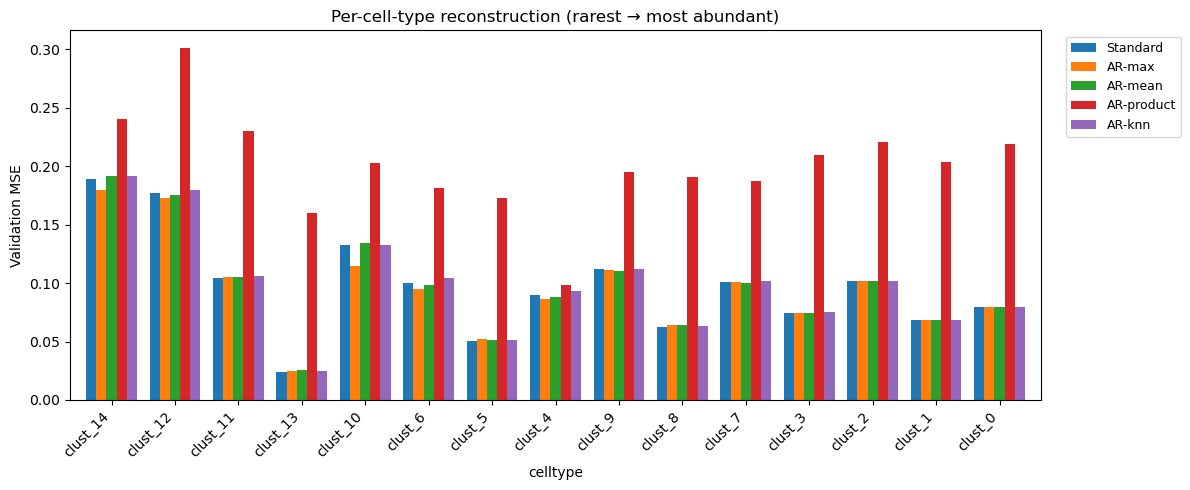

saved /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/rebuttal_analysis/outputs/ar_aggregation_ablation_per_celltype_mse.png


In [19]:
order = pd.Series(y_train).value_counts().sort_values().index.tolist()
mse_df = pd.DataFrame({name: r["per_celltype_mse"] for name, r in results.items()})
mse_df = mse_df.reindex(order)

ax = mse_df.plot(kind="bar", figsize=(12, 5), width=0.8)
ax.set_ylabel("Validation MSE")
ax.set_title("Per-cell-type reconstruction (rarest → most abundant)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig_path = OUT_DIR / "ar_aggregation_ablation_per_celltype_mse.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("saved", fig_path)